In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 머신러닝에서 가장 중요한 것은 데이터고, 그 데이터를 정확히 이해해야만이 좋은 머신러닝을 할 수 있다.

### 아래 전처리 과정을 실행해보면서 데이터를 파악해보자!
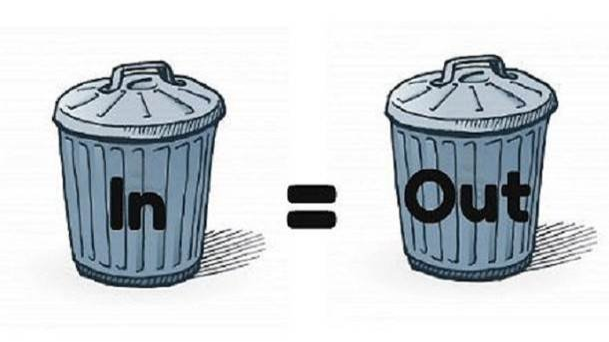![image.png](
)

In [61]:
# 타이타닉 데이터셋 로드
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [62]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [63]:
# train 데이터셋 정보 확인
train.shape

 # 891개 행과 12개의 열

(891, 12)

In [64]:
 # test 데이터셋의 정보확인
test.shape

 # 419개의 행과 11개의 열

(418, 11)

In [65]:
# 학습데이터의 결측치 확인
print(train.isnull().sum())
print()

# 테스트 데이터의 결측치 확인
print(test.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


# Age 결측치 채우기

C:\Users\brian\AppData\Local\Temp\ipykernel_15224\20054312.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train['Age'] = train['Age'].fillna(train['Age'].mean(), inplace=True)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

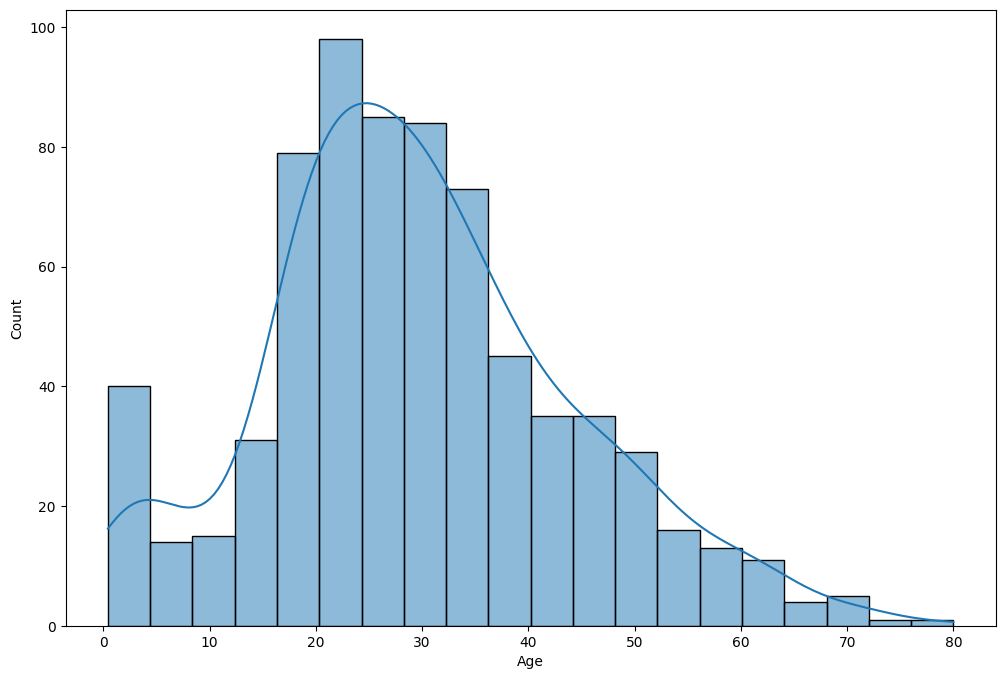

In [66]:
# Age열의 결측치 확인 및 평균 대체
plt.figure(figsize=(12, 8))
sns.histplot(train['Age'], kde=True)

# 정규분포와 유사한 분포를 가져 그냥 mean으로 대체하고 대체 되었는지 확인하기
train['Age'] = train['Age'].fillna(train['Age'].mean(), inplace=True)
train.isnull().sum()    # 채워짐

In [67]:
# test의 Age 결측치를 train의 Age 평균값으로 대체 (데이터 누수 방지)
test['Age'] = test['Age'].fillna(train['Age'].mean(), inplace=True)
test.isnull().sum()    # 채워짐

C:\Users\brian\AppData\Local\Temp\ipykernel_15224\1528107878.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  test['Age'] = test['Age'].fillna(train['Age'].mean(), inplace=True)


PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

# Cabin 결측치 채우기

In [68]:
# Cabin 결측치 채우기
train['Cabin'].unique()

<StringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

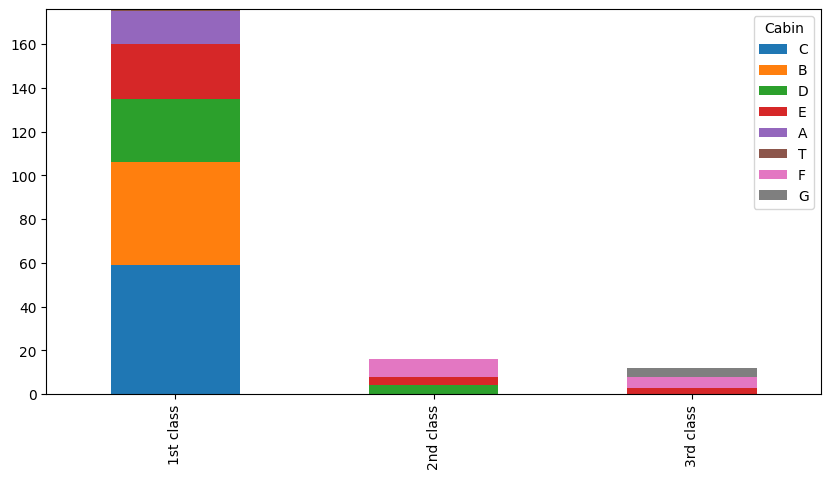

In [69]:
# Cabin은 Pclass별로 가장 많이 탑승한 객실을 기준으로 결측치를 채워줌
cabin_only = train[["Cabin", "Pclass"]].copy()

# Cabin의 앞글자만 따서 값을 대체해준다
cabin_only["Cabin"] = cabin_only['Cabin'].str[:1]


Pclass1 = cabin_only[cabin_only['Pclass']==1]['Cabin'].value_counts() # 1등석의 객실
Pclass2 = cabin_only[cabin_only['Pclass']==2]['Cabin'].value_counts() # 2등석의 객실
Pclass3 = cabin_only[cabin_only['Pclass']==3]['Cabin'].value_counts() # 3등석의 객실


df = pd.DataFrame([Pclass1, Pclass2, Pclass3])

df.index = ['1st class','2nd class', '3rd class']
df.plot(kind='bar',stacked=True, figsize=(10,5))
plt.show()

In [70]:
# train 데이터에서 1등석이면서 Cabin이 결측치면 'B'로 대체
# train 데이터에서 2등석이면서 Cabin이 결측치면 'E'로 대체
# train 데이터에서 3등석이면서 Cabin이 결측치면 'F'로 대체
train.loc[(train.Pclass==1)&(train.Cabin.isnull()),'Cabin']='B'
train.loc[(train.Pclass==2)&(train.Cabin.isnull()),'Cabin']='E'
train.loc[(train.Pclass==3)&(train.Cabin.isnull()),'Cabin']='F'


# 아래 코드도 실행해주세요
train["Cabin"] = train["Cabin"].str.slice(0,1)

train.isnull().sum()    # 채워짐

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       2
dtype: int64

In [71]:
# test의 Cabin 결측치도 같은 방식으로 채우기
test.loc[(test.Pclass==1)&(test.Cabin.isnull()),'Cabin']='B'
test.loc[(test.Pclass==2)&(test.Cabin.isnull()),'Cabin']='E'
test.loc[(test.Pclass==3)&(test.Cabin.isnull()),'Cabin']='F'

test["Cabin"] = test["Cabin"].str.slice(0,1)

test.isnull().sum()    # 채워짐

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Cabin          0
Embarked       0
dtype: int64

# Embarked

In [72]:
# Embarked는 최빈값으로 대체

train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])
train.isnull().sum()    # 채워짐

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [73]:
# test의 Embarked 결측치를 train의 Embarked 최빈값으로 대체 (데이터 누수 방지)
test['Embarked'] = test['Embarked'].fillna(train['Embarked'].mode()[0])
test.isnull().sum()    # 채워짐

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Cabin          0
Embarked       0
dtype: int64

In [74]:
# test의 Fare 결측치를 train의 Fare 평균값으로 대체 (데이터 누수 방지)
test['Fare'] = test['Fare'].fillna(train['Fare'].mean(), inplace=True)

C:\Users\brian\AppData\Local\Temp\ipykernel_15224\1031570051.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  test['Fare'] = test['Fare'].fillna(train['Fare'].mean(), inplace=True)


In [75]:
# 최종 train 데이터를 X와 y로 나누기
X = train.drop(['PassengerId', 'Name', 'Ticket', 'Survived'], axis=1)
y = train['Survived']


# Test 데이터는 PassengerId, Name, Ticket 열을 제외
X_test = test.drop(['PassengerId', 'Name', 'Ticket'], axis=1)


# 스케일링 & 라벨링


In [76]:
# train_test_split을 통해 학습 데이터와 검증 데이터를 나누기
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y,test_size=0.2, random_state=42)

X_train.shape, X_val.shape, y_train.shape, y_val.shape


((712, 8), (179, 8), (712,), (179,))

In [77]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,1,male,45.500000,0,0,28.5000,C,S
733,2,male,23.000000,0,0,13.0000,E,S
382,3,male,32.000000,0,0,7.9250,F,S
704,3,male,26.000000,1,0,7.8542,F,S
813,3,female,6.000000,4,2,31.2750,F,S
...,...,...,...,...,...,...,...,...
106,3,female,21.000000,0,0,7.6500,F,S
270,1,male,29.699118,0,0,31.0000,B,S
860,3,male,41.000000,2,0,14.1083,F,S
435,1,female,14.000000,1,2,120.0000,B,S


In [78]:
X_val

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,3,male,29.699118,1,1,15.2458,F,C
439,2,male,31.000000,0,0,10.5000,E,S
840,3,male,20.000000,0,0,7.9250,F,S
720,2,female,6.000000,0,1,33.0000,E,S
39,3,female,14.000000,1,0,11.2417,F,C
...,...,...,...,...,...,...,...,...
433,3,male,17.000000,0,0,7.1250,F,S
773,3,male,29.699118,0,0,7.2250,F,C
25,3,female,38.000000,1,5,31.3875,F,S
84,2,female,17.000000,0,0,10.5000,E,S


In [79]:
y_train

331    0
733    0
382    0
704    0
813    0
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 712, dtype: int64

In [80]:
y_val

709    1
439    0
840    0
720    1
39     1
      ..
433    0
773    0
25     1
84     1
10     1
Name: Survived, Length: 179, dtype: int64

In [81]:
# 표준화 하기
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# 스케일러를 통해서 X_train의 Age와 Fare를 스케일링해주세요  fit_transform 사용
X_train[['Age', 'Fare']] = scaler.fit_transform(X_train[['Age', 'Fare']])
# X_val또한 스케일링 해주세요
X_val[['Age', 'Fare']] = scaler.transform(X_val[['Age', 'Fare']])


# test 데이터에도 동일한 스케일링 적용
X_test[['Age', 'Fare']] = scaler.transform(X_test[['Age', 'Fare']])

In [82]:
# 순서가 있는 애들은 라벨인코딩을.
# 순서가 없는 애들은 원핫 인코딩을 진행한다.


# cabin과 embarked는 순서가 없는 애들이므로 원핫인코딩을 진행한다.

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OneHotEncoder

# 각 인코더 따로 만들기
encoder_cabin = OneHotEncoder(handle_unknown='ignore', sparse_output=False) # hadle_unknown='ignore'는 학습 데이터에 없는 값이 테스트 데이터에 있을 때 무시하도록 설정
encoder_embarked = OneHotEncoder(handle_unknown='ignore', sparse_output=False) # sparse_output=False는 희소 행렬이 아닌 일반 배열로 반환하도록 설정 걍 판다스로 붙이기 가능!

# Cabin 인코딩
cabin_encoded = encoder_cabin.fit_transform(X_train[['Cabin']])
cabin_encoded_val = encoder_cabin.transform(X_val[['Cabin']])
cabin_encoded_df = pd.DataFrame(cabin_encoded, columns=encoder_cabin.get_feature_names_out(['Cabin']), index=X_train.index)
cabin_encoded_val_df = pd.DataFrame(cabin_encoded_val, columns=encoder_cabin.get_feature_names_out(['Cabin']), index=X_val.index)

# Embarked 인코딩
embarked_encoded = encoder_embarked.fit_transform(X_train[['Embarked']])
embarked_encoded_val = encoder_embarked.transform(X_val[['Embarked']])
embarked_encoded_df = pd.DataFrame(embarked_encoded, columns=encoder_embarked.get_feature_names_out(['Embarked']), index=X_train.index)
embarked_encoded_val_df = pd.DataFrame(embarked_encoded_val, columns=encoder_embarked.get_feature_names_out(['Embarked']), index=X_val.index)

# 원래 열 삭제하고 인코딩된 열 붙이기
X_train = X_train.drop(['Cabin', 'Embarked'], axis=1)
X_val = X_val.drop(['Cabin', 'Embarked'], axis=1)

X_train = pd.concat([X_train, cabin_encoded_df, embarked_encoded_df], axis=1)
X_val = pd.concat([X_val, cabin_encoded_val_df, embarked_encoded_val_df], axis=1)

# test 데이터에도 동일한 인코딩 적용
cabin_encoded_test = encoder_cabin.transform(X_test[['Cabin']])
embarked_encoded_test = encoder_embarked.transform(X_test[['Embarked']])
cabin_encoded_test_df = pd.DataFrame(cabin_encoded_test, columns=encoder_cabin.get_feature_names_out(['Cabin']), index=X_test.index)
embarked_encoded_test_df = pd.DataFrame(embarked_encoded_test, columns=encoder_embarked.get_feature_names_out(['Embarked']), index=X_test.index)
X_test = X_test.drop(['Cabin', 'Embarked'], axis=1)
X_test = pd.concat([X_test, cabin_encoded_test_df, embarked_encoded_test_df], axis=1)

# 최종적으로 인코딩된 train, validation, test 데이터 확인
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (712, 17)
X_val shape: (179, 17)
X_test shape: (418, 17)


### 중요!, 남자는 1이고 여자는 0인 것 기억하기

In [83]:
# train , val, test 모두 성별은 남자는 1 여자는 0으로 변환
X_train['Sex'] = X_train['Sex'].replace({'male': 1, 'female': 0})
X_val['Sex'] = X_val['Sex'].replace({'male': 1, 'female': 0})
X_test['Sex'] = X_test['Sex'].replace({'male': 1, 'female': 0})

# 모델 선정하고 Fit 해보기

In [84]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier(n_neighbors= 5) # k값 설정

knn.fit(X_train, y_train) # 학습 데이터로 모델 학습

# 검증 데이터로 예측
y_train_pred_knn = knn.predict(X_train)
y_val_pred_knn = knn.predict(X_val)

# accuacy_score(실제값, 예측값)
train_acc_knn = accuracy_score(y_train, y_train_pred_knn)
val_acc_knn = accuracy_score(y_val, y_val_pred_knn)

# 정확도 평가
print(f"Train Accuracy (KNN): {train_acc_knn}")
print(f"Validation Accuracy (KNN): {val_acc_knn}")

# 혼동행렬 출력
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred_knn))


Train Accuracy (KNN): 0.8497191011235955
Validation Accuracy (KNN): 0.8379888268156425

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.85      0.88      0.86       105
           1       0.82      0.78      0.80        74

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



In [85]:
# fit 후에 모델이 학습한 데이터 정보
print(f"모델이 학습한 특성 개수: {knn.n_features_in_}")
print(f"모델이 학습한 샘플 개수: {knn._fit_X.shape[0]}")

모델이 학습한 특성 개수: 17
모델이 학습한 샘플 개수: 712


In [86]:
# 훈련 데이터 개수 및 특성 개수
print(f"훈련 데이터 개수: {X_train.shape[0]}")
print(f"특성 개수: {X_train.shape[1]}")
print(f"훈련 라벨 개수: {y_train.shape[0]}")

# 검증 데이터 개수
print(f"\n검증 데이터 개수: {X_val.shape[0]}")
print(f"검증 라벨 개수: {y_val.shape[0]}")

# 전체 데이터 개수
print(f"\n전체 데이터 개수: {X_train.shape[0] + X_val.shape[0]}")

훈련 데이터 개수: 712
특성 개수: 17
훈련 라벨 개수: 712

검증 데이터 개수: 179
검증 라벨 개수: 179

전체 데이터 개수: 891


In [87]:
# 클래스 종류 확인
print("예측 대상 클래스:")
print(f"클래스 종류: {knn.classes_}")
print(f"클래스 개수: {len(knn.classes_)}개")

# y_train의 클래스 분포
import pandas as pd
print("\n훈련 데이터 클래스 분포:")
print(pd.Series(y_train).value_counts().sort_index())

# 예측된 결과의 분포
print("\n검증 데이터 예측 결과 분포:")
print(pd.Series(y_val_pred_knn).value_counts().sort_index())

# 실제 검증 데이터 분포
print("\n검증 데이터 실제 분포:")
print(pd.Series(y_val).value_counts().sort_index())

예측 대상 클래스:
클래스 종류: [0 1]
클래스 개수: 2개

훈련 데이터 클래스 분포:
Survived
0    444
1    268
Name: count, dtype: int64

검증 데이터 예측 결과 분포:
0    108
1     71
Name: count, dtype: int64

검증 데이터 실제 분포:
Survived
0    105
1     74
Name: count, dtype: int64


In [88]:
# 정확히 맞춘 개수 계산
correct = (y_val == y_val_pred_knn).sum()
print(f"\n정확히 예측한 승객: {correct}명 / {len(y_val)}명")
print(f"정확도: {val_acc_knn*100:.2f}%")

# 틀린 개수
wrong = (y_val != y_val_pred_knn).sum()
print(f"틀리게 예측한 승객: {wrong}명")


정확히 예측한 승객: 150명 / 179명
정확도: 83.80%
틀리게 예측한 승객: 29명


In [89]:
from sklearn.metrics import confusion_matrix

# 혼동행렬로 어떤 오류가 많은지 확인
cm = confusion_matrix(y_val, y_val_pred_knn)
print("\n혼동행렬:")
print(f"              예측: 사망(0)  예측: 생존(1)")
print(f"실제 사망(0):    {cm[0,0]:4d}        {cm[0,1]:4d}")
print(f"실제 생존(1):    {cm[1,0]:4d}        {cm[1,1]:4d}")

# 오류 유형 분석
false_negative = cm[1,0]  # 생존자를 사망으로 예측
false_positive = cm[0,1]  # 사망자를 생존으로 예측

print(f"\n오류 분석:")
print(f"생존자를 사망으로 잘못 예측: {false_negative}명")
print(f"사망자를 생존으로 잘못 예측: {false_positive}명")
print(f"총 오류: {false_negative + false_positive}명")


혼동행렬:
              예측: 사망(0)  예측: 생존(1)
실제 사망(0):      92          13
실제 생존(1):      16          58

오류 분석:
생존자를 사망으로 잘못 예측: 16명
사망자를 생존으로 잘못 예측: 13명
총 오류: 29명


In [90]:
# KNN 다양한 K값 시도
for k in [1, 3, 5, 7, 10, 15, 20]:
    knn_test = KNeighborsClassifier(n_neighbors=k)
    knn_test.fit(X_train, y_train)
    val_pred = knn_test.predict(X_val)
    acc = accuracy_score(y_val, val_pred)
    print(f"K={k:2d}: 정확도 {acc*100:.2f}%")

K= 1: 정확도 75.98%
K= 3: 정확도 83.24%
K= 5: 정확도 83.80%
K= 7: 정확도 79.89%
K=10: 정확도 81.01%
K=15: 정확도 82.12%
K=20: 정확도 81.01%


In [91]:
# logistic regression
from sklearn.linear_model import LogisticRegression

# max_iter는 반복 횟수를 늘려서 수렴을 보장
# 재현성을 위해 random_state(랜덤 시드) 지정
log_reg = LogisticRegression(max_iter=1000, random_state=42)


# 학습하기
log_reg.fit(X_train, y_train)

# 검증 데이터로 예측
y_train_pred_log = log_reg.predict(X_train)
y_val_pred_log = log_reg.predict(X_val)

# 예측 결과 확인
# print("Validation Predictions (Logistic Regression):", y_val_pred_log)
train_acc_log = accuracy_score(y_train, y_train_pred_log)
val_acc_log = accuracy_score(y_val, y_val_pred_log)

# 정확도 평가
print(f"Train Accuracy (Logistic Regression): {train_acc_log}")
print(f"Validation Accuracy (Logistic Regression): {val_acc_log}")

# 혼동행렬 출력
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred_log))


Train Accuracy (Logistic Regression): 0.8103932584269663
Validation Accuracy (Logistic Regression): 0.7988826815642458

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.81      0.87      0.83       105
           1       0.79      0.70      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [92]:
# 각 샘플이 0/1일 확률 (0과 1 사이의 확률값으로 예측하는 로지스틱 회귀분석의 특성을 파악 가능!)
y_val_proba = log_reg.predict_proba(X_val)

y_val_proba[:5]

array([[0.8918467 , 0.1081533 ],
       [0.73572007, 0.26427993],
       [0.8732557 , 0.1267443 ],
       [0.08974978, 0.91025022],
       [0.25639022, 0.74360978]])

In [93]:
# 실제 데이터와 예측 비교!
val_result = X_val.copy()
val_result['P_survived'] = log_reg.predict_proba(X_val)[:, 1]
val_result['y_pred'] = log_reg.predict(X_val)
val_result['y_true'] = y_val.values

val_result.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin_A,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Embarked_C,Embarked_Q,Embarked_S,P_survived,y_pred,y_true
709,3,1,0.012390,1,1,-0.333901,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.108153,0,1
439,2,1,0.112570,0,0,-0.425284,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.264280,0,0
840,3,1,-0.734533,0,0,-0.474867,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.126744,0,0
720,2,0,-1.812666,0,1,0.007966,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.910250,1,1
39,3,0,-1.196590,1,0,-0.411002,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.743610,1,1


In [94]:
# 어떤 특성이 중요한지
feature_names = X_train.columns

feature_importance = pd.DataFrame({
    '특성': feature_names,
    'Odds Ratio': np.exp(log_reg.coef_[0])
}).sort_values('Odds Ratio', ascending=False)
feature_importance

,특성,Odds Ratio
9,Cabin_D,1.813377
10,Cabin_E,1.608066
11,Cabin_F,1.287670
14,Embarked_C,1.243796
5,Fare,1.240589
15,Embarked_Q,1.084879
4,Parch,0.891388
6,Cabin_A,0.870435
7,Cabin_B,0.792223
13,Cabin_T,0.772850


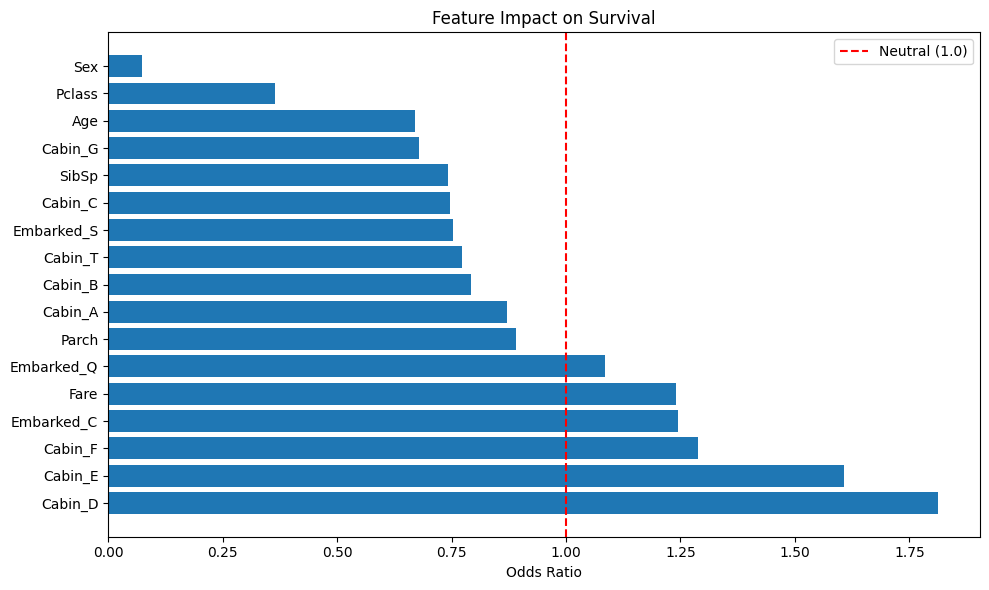

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['특성'], feature_importance['Odds Ratio'])
plt.axvline(x=1, color='r', linestyle='--', label='Neutral (1.0)')
plt.xlabel('Odds Ratio')
plt.title('Feature Impact on Survival')
plt.legend()
plt.tight_layout()
plt.show()

In [96]:
import numpy as np

coef = log_reg.coef_[0]          # 로지스틱 회귀 계수
sex_idx = X_train.columns.get_loc('Sex')

coef[sex_idx]

np.float64(-2.5936319156833645)

In [97]:
import pandas as pd
import numpy as np

sex_idx = X_train.columns.get_loc('Sex')

summary = {
    "coef": log_reg.coef_[0][sex_idx],
    "odds_ratio": np.exp(log_reg.coef_[0][sex_idx]),
    "male_survival_rate": train[train['Sex']=='male']['Survived'].mean(),
    "female_survival_rate": train[train['Sex']=='female']['Survived'].mean()
}

summary


{'coef': np.float64(-2.5936319156833645),
 'odds_ratio': np.float64(0.07474806781431388),
 'male_survival_rate': np.float64(0.18890814558058924),
 'female_survival_rate': np.float64(0.7420382165605095)}

### 해석해보자!
Coef (가중치): -2.59
- 성별이 남성으로 갈수록 생존 확률 급격히 감소
- 절댓값이 2.59로 매우 큰 → 가장 중요한 특성

Odds Ratio: 0.075
- 남성의 생존 Odds가 여성의 7.5%에 불과
- 역으로 계산: 여성이 남성보다 13.4배 (1/0.075) 생존 가능성 높음

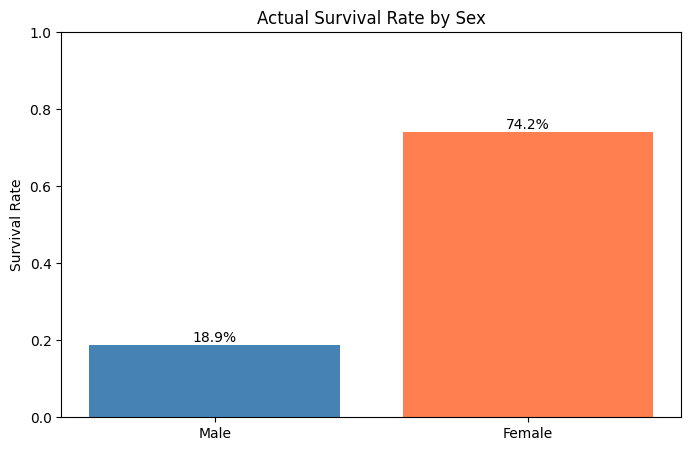


여성이 남성보다 3.9배 더 생존


In [98]:
# 실제 데이터와 비교해보자!
import matplotlib.pyplot as plt

# 생존율 비교
labels = ['Male', 'Female']
survival_rates = [summary['male_survival_rate'],
                  summary['female_survival_rate']]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, survival_rates, color=['steelblue', 'coral'])
plt.ylabel('Survival Rate')
plt.title('Actual Survival Rate by Sex')
plt.ylim(0, 1)

# 막대 위에 수치 표시
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{survival_rates[i]:.1%}',
             ha='center', va='bottom')

plt.show()

print(f"\n여성이 남성보다 {summary['female_survival_rate']/summary['male_survival_rate']:.1f}배 더 생존")

In [99]:
# 실행 x (궁금하면 추후 실행)
# 중요도 낮은 특성 제거 고려
# low_importance = feature_importance[
#     (feature_importance['Odds Ratio'] > 0.85) &
#     (feature_importance['Odds Ratio'] < 1.15)
# ]
# print("제거 고려 특성 (거의 영향 없음):")
# print(low_importance['특성'].tolist())
# ['Embarked_Q', 'Parch'] 같은 것들


In [100]:
# Logistic Regression이 학습하는 것
# y = sigmoid(w1*x1 + w2*x2 + ... + w17*x17 + b)
# max_iter만큼 반복하며 w1~w17과 b를 최적화

# 학습된 가중치 확인
print("학습된 가중치:")
print(log_reg.coef_)
print(f"\n편향(bias): {log_reg.intercept_}")

학습된 가중치:
[[-1.01145727 -2.59363192 -0.39915887 -0.29928767 -0.11497523  0.21558647
  -0.13876194 -0.23291184 -0.29206463  0.59519101  0.47503252  0.25283422
  -0.38617    -0.2576703   0.21816803  0.0814689  -0.28415788]]

편향(bias): [3.53844995]


In [101]:
import numpy as np

# 가중치를 Odds Ratio로 변환
feature_names = X_train.columns
weights = log_reg.coef_[0]
odds_ratios = np.exp(weights)

# Odds Ratio 해석
odds_df = pd.DataFrame({
    '특성': feature_names,
    '가중치': weights,
    'Odds Ratio': odds_ratios,
    '해석': ['생존 확률 증가' if or_ > 1 else '생존 확률 감소'
            for or_ in odds_ratios]
})

print("Odds Ratio 해석:")
print(odds_df.sort_values('Odds Ratio', ascending=False))

Odds Ratio 해석:
            특성       가중치  Odds Ratio        해석
9      Cabin_D  0.595191    1.813377  생존 확률 증가
10     Cabin_E  0.475033    1.608066  생존 확률 증가
11     Cabin_F  0.252834    1.287670  생존 확률 증가
14  Embarked_C  0.218168    1.243796  생존 확률 증가
5         Fare  0.215586    1.240589  생존 확률 증가
15  Embarked_Q  0.081469    1.084879  생존 확률 증가
4        Parch -0.114975    0.891388  생존 확률 감소
6      Cabin_A -0.138762    0.870435  생존 확률 감소
7      Cabin_B -0.232912    0.792223  생존 확률 감소
13     Cabin_T -0.257670    0.772850  생존 확률 감소
16  Embarked_S -0.284158    0.752648  생존 확률 감소
8      Cabin_C -0.292065    0.746720  생존 확률 감소
3        SibSp -0.299288    0.741346  생존 확률 감소
12     Cabin_G -0.386170    0.679655  생존 확률 감소
2          Age -0.399159    0.670884  생존 확률 감소
0       Pclass -1.011457    0.363689  생존 확률 감소
1          Sex -2.593632    0.074748  생존 확률 감소


In [102]:
# 가중치가 -2.59인 특성
# Odds Ratio = exp(-2.59) = 0.075
print(f"성별(남성) Odds Ratio: {np.exp(-2.59):.3f}")
print("→ 남성일 경우 생존 Odds가 약 0.075배 (92.5% 감소)")

# 가중치가 +0.59인 특성
print(f"\nOdds Ratio: {np.exp(0.59):.3f}")
print("→ 이 특성이 1 증가하면 생존 Odds가 1.8배 증가")

# 여성을 기준(1.0)으로 봤을 때, 남성의 생존 Odds는 7.5%만 남음
# 다시 말해, 남성은 여성보다 생존 Odds가 92.5% 감소
# 역으로 계산하면? 여성은 남성보다 13.3배 더 생존 가능

성별(남성) Odds Ratio: 0.075
→ 남성일 경우 생존 Odds가 약 0.075배 (92.5% 감소)

Odds Ratio: 1.804
→ 이 특성이 1 증가하면 생존 Odds가 1.8배 증가


###
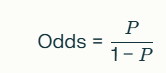

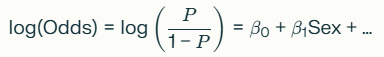

### -2.59의 도출은 위 수식으로 도출됨!

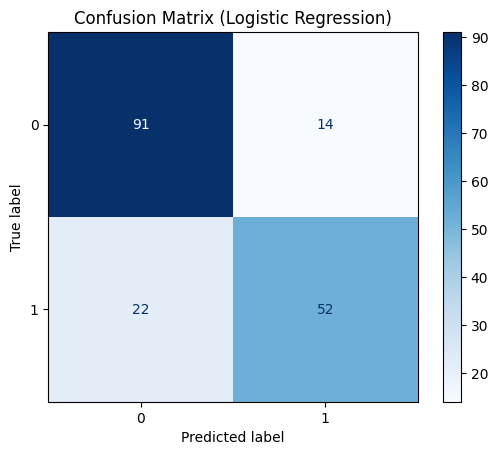

In [103]:
# logistic regression 혼동행렬
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_log = confusion_matrix(y_val, y_val_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=log_reg.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Logistic Regression)")
plt.show()


In [104]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# n_estimators는 트리의 개수
# 재현성을 위해 random_state(랜덤 시드) 지정
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 학습하기
rf.fit(X_train, y_train)

# 검증 데이터로 예측
y_train_pred_rf = rf.predict(X_train)
y_val_pred_rf = rf.predict(X_val)

# 예측 결과 확인
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
val_acc_rf = accuracy_score(y_val, y_val_pred_rf)

# 정확도 평가
print(f"Train Accuracy (Random Forest): {train_acc_rf}")
print(f"Validation Accuracy (Random Forest): {val_acc_rf}")

# 혼동행렬 출력
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred_rf))


Train Accuracy (Random Forest): 0.9831460674157303
Validation Accuracy (Random Forest): 0.8100558659217877

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



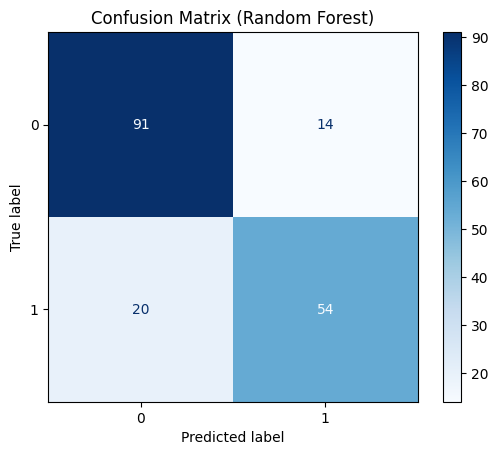

In [105]:
# Random Forest 혼동행렬
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_val, y_val_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=rf.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Random Forest)")
plt.show()


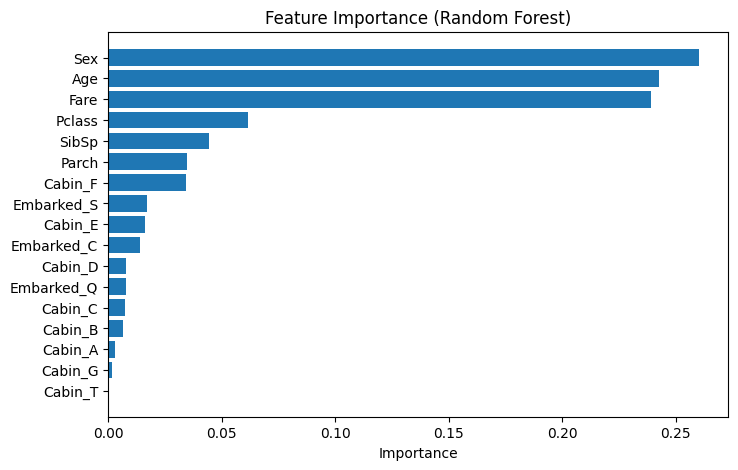

In [106]:
# Random Forest 변수중요도
import pandas as pd
import matplotlib.pyplot as plt

importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance_df["feature"],
    feature_importance_df["importance"]
)
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

# 위 로지스틱의 중요도와 양상이 비슷한 것을 알 수 있다!

# 위 모델 중 최고성능모델 확인하고 실제 Test 세트 predict 하고 제출해서 점수 보기

In [107]:
# (ex. Random Forest가 최고성능모델이라면 해당모델로 test)
y_test_pred_rf = rf.predict(X_test)

# 제출 파일 생성
submission_rf = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': y_test_pred_rf
})

submission_rf.to_csv('submission_rf.csv', index=False)

print("submission_rf.csv 저장 완료")


submission_rf.csv 저장 완료


https://www.kaggle.com/competitions/titanic/overview
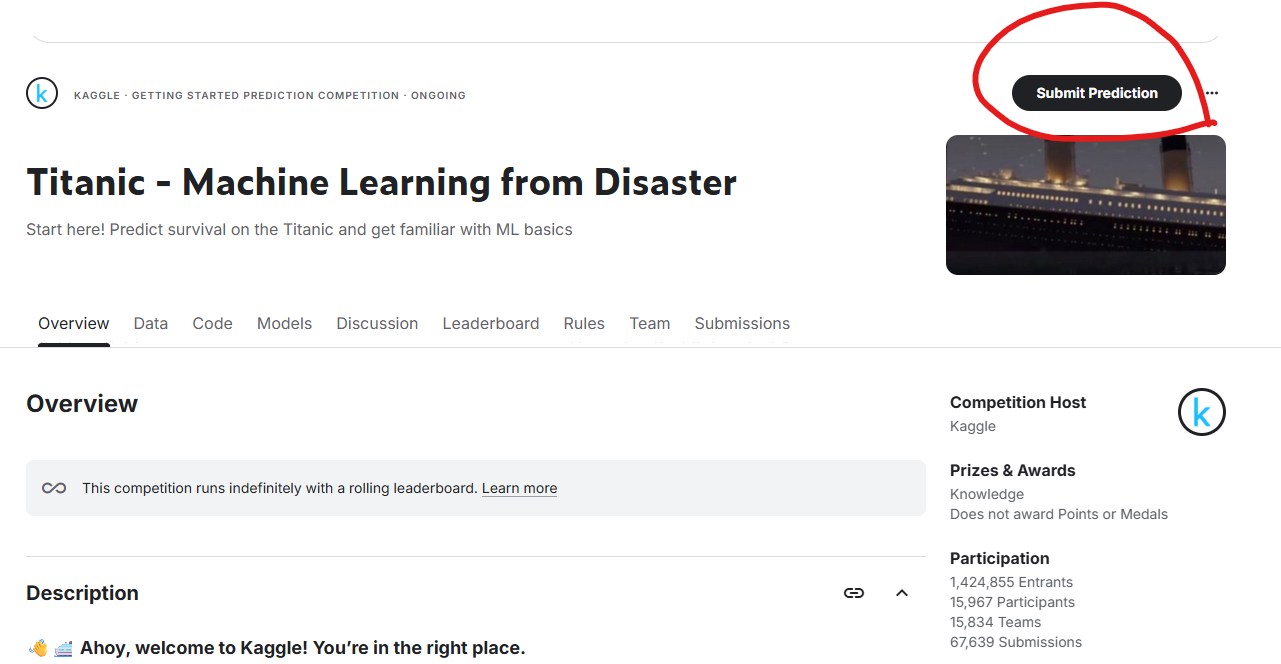

위 캐글 타이타닉 생존자예측 경진대회에서 제출해보고 아래 예시처럼 결과 확인해보기

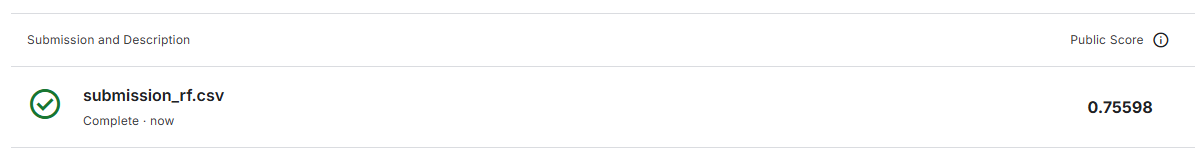

### 전체모델 Test예측

# 평가

## 새롭게 배우는 내용 해보자! (모델평가 : 정밀도, 재현율, f1score 실습 및 ROC)

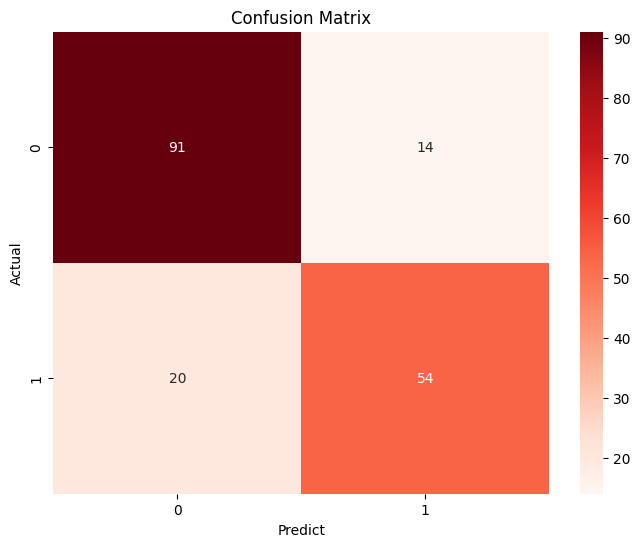

In [108]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
from matplotlib import pyplot as plt

# validation 데이터를 test 데이터로 사용
y_test = y_val
pred = y_val_pred_rf  # 또는 y_val_pred_knn, y_val_pred_log 중 선택

# Confusion Matrix
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predict')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### 위 혼동행렬을 가지고 아래 정밀도, 재현율, F1 Score을 직접 계산해보자!
- 어떻게 아래의 값들이 나왔을까?

In [109]:
# Precision (정밀도)
# 다중 분류 - average='weighted'
# 이진 분류 - average='binary' (기본값, 생략 가능)
precision = precision_score(y_test, pred, average='binary')
print(f"Precision: {precision:.4f}")

Precision: 0.7941


In [110]:
# Recall (재현율)
recall = recall_score(y_test, pred)
print(f"Recall: {recall:.4f}")

Recall: 0.7297


In [111]:
# F1 Score
f1 = f1_score(y_test, pred)
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.7606


### 랜덤 포레스트 모델의 ROC 결과 해석해보기
- 어느 쪽에 치우쳐야 좋은 ROC 곡선인가?

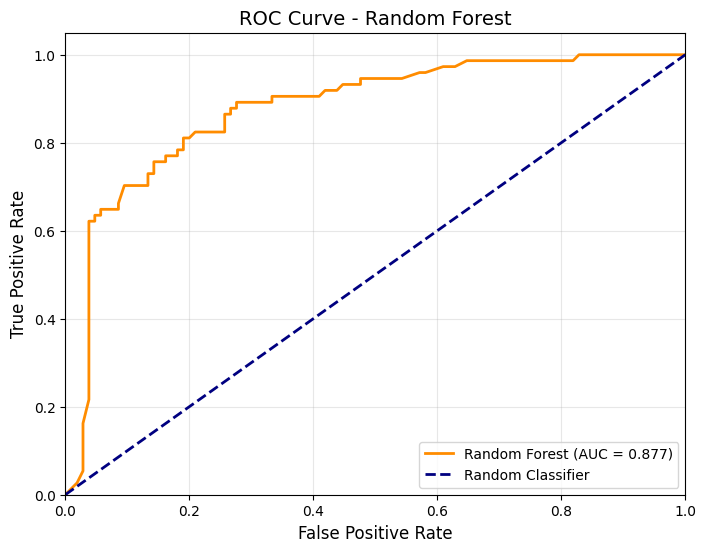

Model Performance Metrics
Precision: 0.7941
Recall:    0.7297
F1 Score:  0.7606
ROC AUC:   0.8769


In [112]:
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# 확률 예측 (ROC용)
y_test = y_val
pred = y_val_pred_rf
y_test_proba = rf.predict_proba(X_val)[:, 1]  # positive class 확률

# ROC Curve만 그리기
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Random Forest', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 성능 지표 출력
print("="*50)
print("Model Performance Metrics")
print("="*50)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")


### 정밀도, 재현율, f1 score 복습 및 해석!

In [113]:
# 정밀도 (양성 예측 정확도)
# TP / (TP + FP)
from sklearn.metrics import precision_score, recall_score

precision_score(y_test, pred)
# 무조건 양성으로 판단하면 좋은 정밀도를 얻기 때문에 유용하지는 않음

0.7941176470588235

In [114]:
# 재현율(recall) TP / (TP + FN)
# 정확하게 감지한 양성 샘플의 비율
# 민감도(sensitivity) 또는 True Positive Rate(TPR) 이라고도 부름
recall_score(y_test, pred)

0.7297297297297297

In [115]:
# f1 score
# 정밀도와 재현율의 조화 평균을 나타내는 지표
f1_score(y_test, pred)

0.7605633802816901

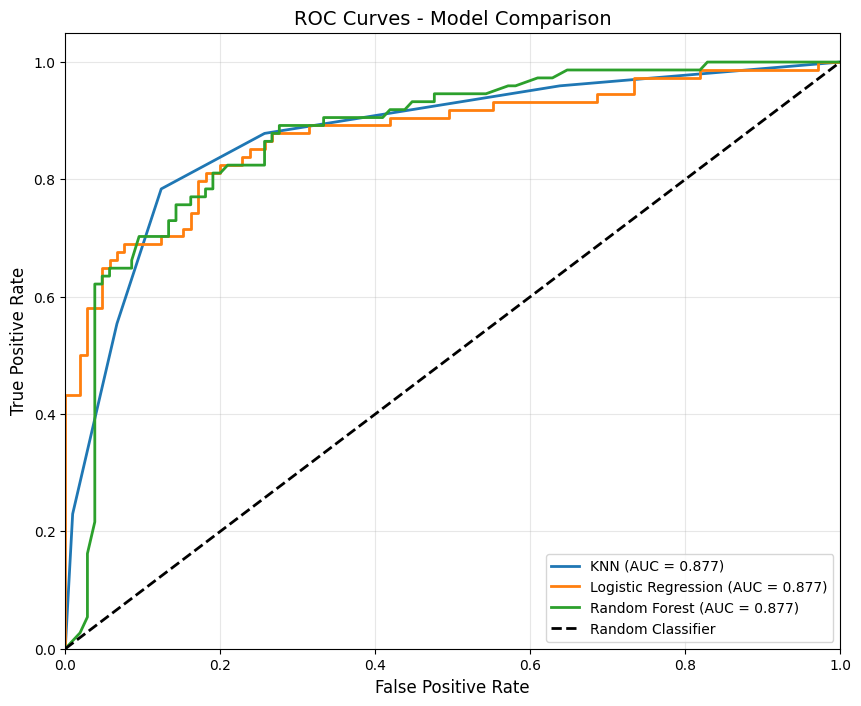

KNN AUC: 0.8772
Logistic Regression AUC: 0.8772
Random Forest AUC: 0.8769


In [116]:
# 앞서 만든 3가지 모델 KNN, 로지스틱, 랜덤포레스트 ROC 비교 후 해석해보자
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# 각 모델의 확률 예측
y_val_proba_knn = knn.predict_proba(X_val)[:, 1]
y_val_proba_log = log_reg.predict_proba(X_val)[:, 1]
y_val_proba_rf = rf.predict_proba(X_val)[:, 1]

# ROC curve 계산
fpr_knn, tpr_knn, _ = roc_curve(y_val, y_val_proba_knn)
fpr_log, tpr_log, _ = roc_curve(y_val, y_val_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_val_proba_rf)

# AUC 계산
auc_knn = auc(fpr_knn, tpr_knn)
auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)

# ROC 곡선 그리기
plt.figure(figsize=(10, 8))
plt.plot(fpr_knn, tpr_knn, lw=2, label=f'KNN (AUC = {auc_knn:.3f})')
plt.plot(fpr_log, tpr_log, lw=2, label=f'Logistic Regression (AUC = {auc_log:.3f})')
plt.plot(fpr_rf, tpr_rf, lw=2, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()

# AUC 점수 출력
print(f"KNN AUC: {auc_knn:.4f}")
print(f"Logistic Regression AUC: {auc_log:.4f}")
print(f"Random Forest AUC: {auc_rf:.4f}")


### 랜덤포레스트 하이퍼파라미터 설정 및 교차검증
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

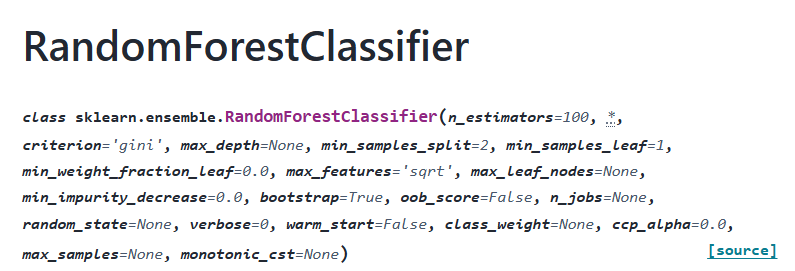

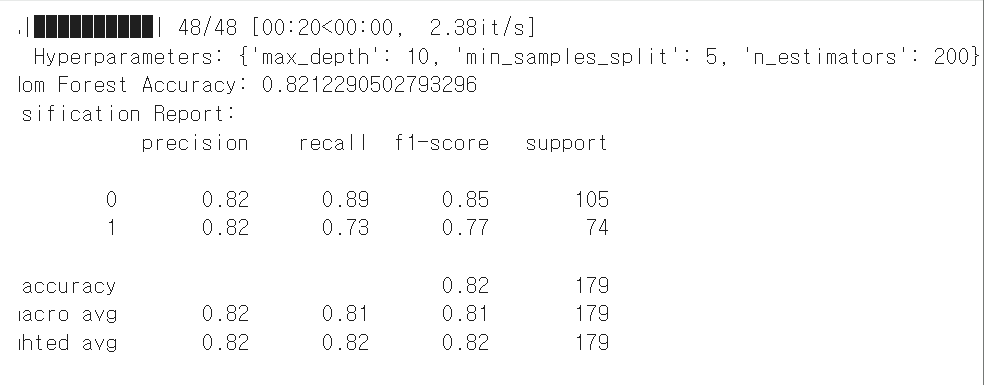

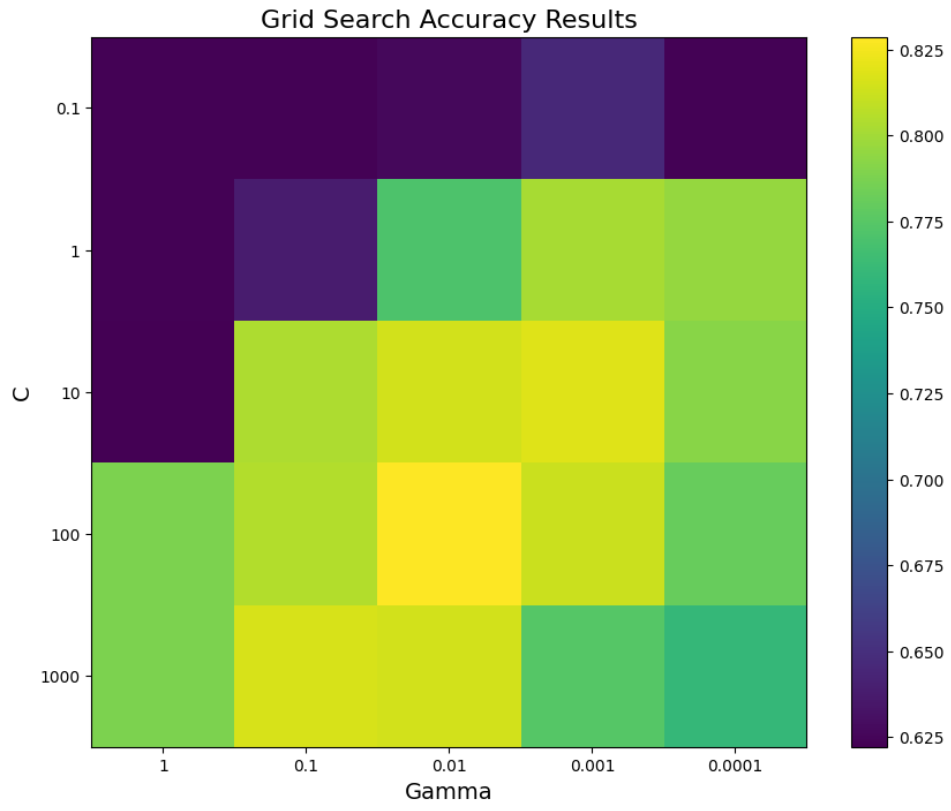

In [117]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 랜덤 포레스트 분류 모델 정의하기(실습) n_estimators = 100
rf_classify_model = RandomForestClassifier(n_estimators=100, random_state=42)  # n_estimators는 트리의 개수

# 랜덤 포레스트 분류 모델 학습하기(실습)
rf_classify_model.fit(X_train, y_train)  # 학습 데이터로 모델 학습

# 검증 데이터로 예측(실습)
y_val_pred_rf = rf_classify_model.predict(X_val)
y_train_pred_rf = rf_classify_model.predict(X_train)

# 예측 결과 확인
# print("Validation Predictions (Random Forest):", y_val_pred_rf)

# 정확도 평가
accuracy_rf_train = accuracy_score(y_train, y_train_pred_rf)
accuracy_rf_val = accuracy_score(y_val, y_val_pred_rf)
print("Train Accuracy (Random Forest):", accuracy_rf_train)
print("Validation Accuracy (Random Forest):", accuracy_rf_val)


Train Accuracy (Random Forest): 0.9831460674157303
Validation Accuracy (Random Forest): 0.8100558659217877


In [118]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

# precision, recall, f1 (실습) 이진 클래스일 경우 average="binary"로 설정 (실습) # 다중 클래스일 경우 average='macro' 또는 'weighted'
precision = precision_score(y_val, y_val_pred_rf, average='binary')
recall = recall_score(y_val, y_val_pred_rf, average='binary')
f1 = f1_score(y_val, y_val_pred_rf, average='binary')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# confusio matirx 그리기 (실습)
conf_matrix = "..."
print("Confusion Matrix:\n", conf_matrix)

Precision: 0.7941176470588235
Recall: 0.7297297297297297
F1 Score: 0.7605633802816901
Confusion Matrix:
 ...
